In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# Define the base path for your data
base_path = '/content/drive/MyDrive/Colab Notebooks/ML/data'

# Load the datasets
X_train = pd.read_csv(f'{base_path}/x_train.csv')
y_train = pd.read_csv(f'{base_path}/y_train.csv')
X_test = pd.read_csv(f'{base_path}/x_test.csv')
y_test = pd.read_csv(f'{base_path}/y_test.csv')

# Display the first few rows of each to verify
print('X_train head:')
display(X_train.head())
print('\ny_train head:')
display(y_train.head())
print('\nX_test head:')
display(X_test.head())
print('\ny_test head:')
display(y_test.head())

X_train head:


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain
0,1.058568,0.907507,1.715086,0.684723,-1.226059,-0.910256,0.641042,-1.030206,1.042084,1.001752,-0.578313,-0.577735
1,0.913626,0.907507,-0.659935,-0.696202,0.413288,-0.910256,0.641042,-1.030206,-0.623556,-0.998252,1.729169,-0.577735
2,1.079274,-1.101919,-0.184931,-1.731895,0.601687,0.808830,0.641042,0.970680,0.308128,-0.998252,1.729169,-0.577735
3,-0.929207,0.907507,-0.184931,-0.005739,-1.226059,0.808830,0.641042,-1.030206,-0.290199,1.001752,-0.578313,-0.577735
4,0.427035,0.907507,0.955079,0.339492,0.548318,0.808830,-1.559960,0.970680,0.135042,-0.998252,1.729169,-0.577735



y_train head:


,Exited
0,1
1,1
2,0
3,0
4,0



X_test head:


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain
0,-0.680735,0.907507,-0.279932,0.684723,-1.226059,0.808830,0.641042,-1.030206,-0.095021,1.001752,-0.578313,-0.577735
1,-1.301915,0.907507,-0.564935,-0.350971,0.877113,0.808830,-1.559960,-1.030206,-0.778941,-0.998252,1.729169,-0.577735
2,-0.970619,-1.101919,0.100072,-0.350971,-1.226059,0.808830,-1.559960,0.970680,0.099469,-0.998252,-0.578313,1.730897
3,-0.121674,0.907507,-0.469934,-0.005739,1.011458,0.808830,-1.559960,-1.030206,-1.147374,-0.998252,-0.578313,1.730897
4,-0.111321,-1.101919,-0.469934,-0.696202,0.023204,-0.910256,0.641042,0.970680,1.200283,-0.998252,-0.578313,1.730897



y_test head:


,Exited
0,0
1,0
2,0
3,0
4,0


In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier
dtc = DecisionTreeClassifier(random_state=42) # Using a random state for reproducibility

# Train the model
dtc.fit(X_train, y_train)

print("Decision Tree Classifier trained successfully!")

Decision Tree Classifier trained successfully!


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy'],
    'class_weight': [None, 'balanced']
}

dtc = DecisionTreeClassifier(random_state=42)


grid_search = GridSearchCV(estimator=dtc, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=2, scoring='f1')


grid_search.fit(X_train, y_train)

print("GridSearchCV completed!")
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best F1-score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 180 candidates, totalling 900 fits
GridSearchCV completed!
Best parameters found: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best F1-score: 0.5705


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Initialize a simpler Decision Tree Classifier
# Setting a low max_depth will reduce complexity and potentially accuracy
simpler_dtc = DecisionTreeClassifier(max_depth=3, random_state=42)

# Train the simpler model
simpler_dtc.fit(X_train, y_train)

print("Simpler Decision Tree Classifier trained successfully!")

Simpler Decision Tree Classifier trained successfully!


--- Simpler Decision Tree Classifier Performance ---
Accuracy: 0.8380
Precision: 0.8739
Recall: 0.2383
F1-Score: 0.3745

Confusion Matrix (Simpler Model):


,Predicted No Churn,Predicted Churn
Actual No Churn,1579,14
Actual Churn,310,97


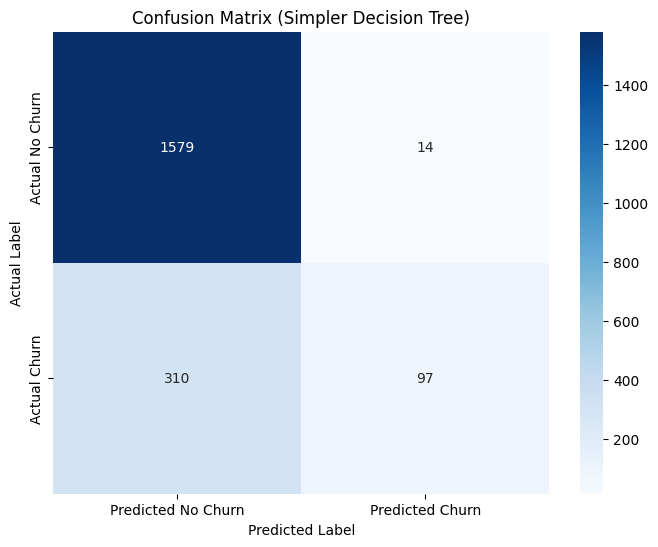


Classification Report (Simpler Model):
              precision    recall  f1-score   support

           0       0.84      0.99      0.91      1593
           1       0.87      0.24      0.37       407

    accuracy                           0.84      2000
   macro avg       0.85      0.61      0.64      2000
weighted avg       0.84      0.84      0.80      2000


--- Comparison with Tuned Model ---
Tuned Accuracy: 0.8555 -> Simpler Accuracy: 0.8380
Tuned F1-Score: 0.5793 -> Simpler F1-Score: 0.3745


In [ ]:
# Make predictions on the test set with the simpler model
y_pred_simpler = simpler_dtc.predict(X_test)

# Calculate evaluation metrics for the simpler model
accuracy_simpler = accuracy_score(y_test, y_pred_simpler)
precision_simpler = precision_score(y_test, y_pred_simpler)
recall_simpler = recall_score(y_test, y_pred_simpler)
f1_simpler = f1_score(y_test, y_pred_simpler)
conf_matrix_simpler = confusion_matrix(y_test, y_pred_simpler)
class_report_simpler = classification_report(y_test, y_pred_simpler)

print("--- Simpler Decision Tree Classifier Performance ---")
print(f"Accuracy: {accuracy_simpler:.4f}")
print(f"Precision: {precision_simpler:.4f}")
print(f"Recall: {recall_simpler:.4f}")
print(f"F1-Score: {f1_simpler:.4f}")

print("\nConfusion Matrix (Simpler Model):")
display(pd.DataFrame(conf_matrix_simpler, index=['Actual No Churn', 'Actual Churn'], columns=['Predicted No Churn', 'Predicted Churn']))

# Visualize Confusion Matrix for Simpler Model
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_simpler, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Churn', 'Predicted Churn'],
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.title('Confusion Matrix (Simpler Decision Tree)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

print("\nClassification Report (Simpler Model):")
print(class_report_simpler)

# Compare with previous results
print("\n--- Comparison with Tuned Model ---")
if 'accuracy_tuned' in globals(): # Check if tuned metrics are available
    print(f"Tuned Accuracy: {accuracy_tuned:.4f} -> Simpler Accuracy: {accuracy_simpler:.4f}")
    print(f"Tuned F1-Score: {f1_tuned:.4f} -> Simpler F1-Score: {f1_simpler:.4f}")
else:
    print("Tuned model metrics not available for direct comparison in this run.")

In [ ]:
import joblib
import os

# Define the path to save the tuned model. Using the same path will overwrite the previous one.
model_save_path_tuned = '/content/drive/MyDrive/Colab Notebooks/ML/decision_tree_churn_model_tuned.joblib'

# Create the directory if it doesn't exist
os.makedirs(os.path.dirname(model_save_path_tuned), exist_ok=True)

# Save the best model from GridSearchCV
joblib.dump(best_dtc, model_save_path_tuned)

print(f"Tuned Decision Tree model saved successfully to: {model_save_path_tuned}")

Tuned Decision Tree model saved successfully to: /content/drive/MyDrive/Colab Notebooks/ML/decision_tree_churn_model_tuned.joblib
